In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/smart_factory_machinery_data.csv")
df.head()


,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Temperature,Defective
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,71.40,1
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,67.07,1
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,84.69,1
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,63.83,1
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,60.22,1


In [61]:
RPM=np.array(df['RPM'])
RPM

array([1660, 4572, 3892, ..., 3430, 3363, 4092])

In [62]:
temp=np.array(df['Temperature'])
temp

array([71.4 , 67.07, 84.69, ..., 64.03, 75.27, 69.29])

In [63]:
x_train,x_test,y_train,y_test=train_test_split(RPM,temp,test_size=0.2)
reg=linear_model.LinearRegression()
reg.fit(x_train.reshape(-1,1),y_train)

LinearRegression()

In [64]:
x_train_simple, x_test_simple, y_train_simple, y_test_simple = train_test_split(temp, RPM, test_size=0.2)
y_pred=reg.predict(x_test_simple.reshape(-1,1))
y_pred

array([53.45911752, 53.41618859, 53.47031985, 53.37754055, 53.42819109,
       53.40118547, 53.39358389, 53.46759929, 53.43667285, 53.36689834,
       53.42030945, 53.51084828, 53.46531881, 53.43055158, 53.3926637 ,
       53.38818276, 53.41586852, 53.3676985 , 53.47396061, 53.42351011,
       53.45471661, 53.45335632, 53.40334592, 53.44767514, 53.50360678,
       53.48420274, 53.4455547 , 53.43091165, 53.4585174 , 53.43591269,
       53.44543467, 53.4691196 , 53.45583684, 53.38074122, 53.44095374,
       53.44487456, 53.40958722, 53.42355012, 53.38238156, 53.44543467,
       53.47460074, 53.38146137, 53.38778268, 53.38294167, 53.45155595,
       53.50284662, 53.49008396, 53.38742261, 53.48900374, 53.47952177,
       53.50952801, 53.46395853, 53.43443239, 53.43007148, 53.39730466,
       53.43231194, 53.36629821, 53.4258306 , 53.51913001, 53.4888037 ,
       53.49160428, 53.48720336, 53.3715393 , 53.42050949, 53.50088621,
       53.50920794, 53.42034946, 53.50340673, 53.48444279, 53.42

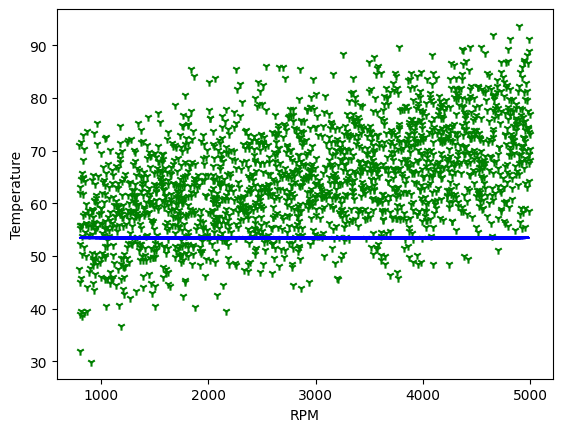

In [65]:
plt.xlabel('RPM')
plt.ylabel('Temperature')
plt.scatter(RPM,temp,color='green',marker='1')
plt.plot(x_test,y_pred,color='blue')

In [66]:
reg.score(x_train.reshape(-1,1),y_train)

0.24711660352031406

Multi - Variabl Linear Regression

In [67]:
df.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Temperature,Defective
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,71.40,1
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,67.07,1
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,84.69,1
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,63.83,1
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,60.22,1


In [68]:
subdf = df[['RPM','Vibration','Pressure','Humidity','Voltage','Current','Load','Operating_Hours','Machine_Mode','Maintenance_Level','Shift_Type']]
subdf.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning


In [69]:
y = df['Temperature']
y.head()

,Temperature
0,71.40
1,67.07
2,84.69
3,63.83
4,60.22


OneHotEncoder

In [70]:
machine_mode_dummies=pd.get_dummies(subdf["Machine_Mode"],prefix='Machine_mode')
machine_mode_dummies.head()

,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard
0,False,True,False
1,False,False,True
2,False,True,False
3,False,False,True
4,True,False,False


In [71]:
Maintenance_dummies=pd.get_dummies(subdf["Maintenance_Level"],prefix='Maintenance_Level')
Maintenance_dummies.head()

,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor
0,True,False,False
1,False,False,True
2,True,False,False
3,False,False,True
4,True,False,False


In [72]:
shift_dummies=pd.get_dummies(df['Shift_Type'],prefix='shift_Type')
shift_dummies.head()

,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
0,False,True,False
1,True,False,False
2,True,False,False
3,False,False,True
4,False,True,False


In [73]:
merged=pd.concat([subdf,machine_mode_dummies,Maintenance_dummies,shift_dummies],axis='columns')
merged.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,False,True,False,True,False,False,False,True,False
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,False,False,True,False,False,True,True,False,False
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,False,True,False,True,False,False,True,False,False
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,False,False,True,False,False,True,False,False,True
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,True,False,False,True,False,False,False,True,False


In [74]:
final=merged.drop(['Machine_Mode',"Maintenance_Level","Shift_Type"],axis="columns")
final.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,False,True,False,True,False,False,False,True,False
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,False,False,True,False,False,True,True,False,False
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,False,True,False,True,False,False,True,False,False
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,False,False,True,False,False,True,False,False,True
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,True,False,False,True,False,False,False,True,False


Train_Test_Split

In [75]:
x_train,x_test,y_train,y_test=train_test_split(final,y,test_size=0.3)
x_train.head()


,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
1272,3055,4.47,50.45,52.14,247.83,15.22,10.43,910,False,True,False,False,False,True,True,False,False
1547,3572,6.44,60.92,59.83,242.61,13.22,12.41,6764,False,False,True,False,False,True,False,False,True
1689,1461,6.78,44.32,74.67,247.55,6.69,48.22,8329,False,False,True,False,True,False,False,False,True
1206,3314,1.68,116.37,59.19,241.06,30.34,68.84,4863,False,True,False,True,False,False,True,False,False
1619,4776,3.93,24.93,45.16,211.34,47.53,59.76,7106,True,False,False,True,False,False,False,True,False


In [76]:
mul_reg=linear_model.LinearRegression()
mul_reg.fit(x_train,y_train)
mul_reg.predict(x_test)

array([74.01623466, 70.85803364, 67.87418837, 65.82998282, 68.0295958 ,
       58.23351485, 60.53113963, 68.1481572 , 68.14010805, 56.14180447,
       71.8878969 , 68.61969053, 57.04669835, 56.04919479, 71.66580847,
       61.71582978, 72.33062517, 65.01684642, 56.30877029, 73.43512881,
       64.77531783, 60.72958303, 70.05530878, 61.15624739, 72.62721869,
       64.96714535, 51.97407378, 69.41803336, 67.34962136, 57.57249052,
       62.44335142, 81.10223587, 53.69428748, 69.12159162, 68.42311415,
       57.62767861, 73.98502916, 81.74843563, 51.62700787, 78.34694951,
       66.91826525, 77.57572785, 49.5608734 , 63.91533845, 60.32858447,
       53.4572978 , 69.91417541, 62.88205018, 67.75833417, 78.97292328,
       53.14438256, 49.6506566 , 81.89866571, 44.2618616 , 72.53045427,
       67.08553298, 85.31714889, 75.88114154, 74.58783285, 67.59848368,
       81.07324581, 73.09881597, 58.42176613, 74.70925615, 42.14020253,
       75.31270712, 72.04046402, 63.40956831, 68.28128844, 61.50

In [77]:
from sklearn import linear_model
mul_reg=linear_model.LinearRegression()
mul_reg.fit(x_train,y_train)
mul_reg.score(x_train,y_train)

0.9600520404862113

In [78]:
import pandas as pd
mul_reg_coef_df = pd.DataFrame(mul_reg.coef_, x_train.columns, columns=['Coefficient'])
mul_reg_coef_df

,Coefficient
RPM,0.003928
Vibration,1.790392
Pressure,0.124422
Humidity,0.029241
Voltage,-0.007094
Current,0.057904
Load,0.082920
Operating_Hours,0.000329
Machine_mode_Eco,-6.144758
Machine_mode_High-Speed,6.983773


In [79]:
print(mul_reg.intercept_)

30.307634600035776


Save and Load Using Pickle

In [80]:
import pickle
with open('model_pickle','wb') as file:
  pickle.dump(mul_reg,file)
with open('model_pickle','rb') as file:
  p_m=pickle.load(file)
print(p_m.coef_)

[ 3.92817704e-03  1.79039156e+00  1.24422298e-01  2.92406687e-02
 -7.09374824e-03  5.79035832e-02  8.29198388e-02  3.29450963e-04
 -6.14475806e+00  6.98377254e+00 -8.39014482e-01  4.57248014e-01
 -4.70831076e+00  4.25106274e+00 -3.37719234e-01 -1.39458067e+00
  1.73229990e+00]


In [81]:
print(p_m.intercept_)

30.307634600035776


Save and Load Using Joblib

In [82]:
import joblib
joblib.dump(mul_reg,"Model_reg")
mj=joblib.load("Model_reg")
print(mj.coef_)

[ 3.92817704e-03  1.79039156e+00  1.24422298e-01  2.92406687e-02
 -7.09374824e-03  5.79035832e-02  8.29198388e-02  3.29450963e-04
 -6.14475806e+00  6.98377254e+00 -8.39014482e-01  4.57248014e-01
 -4.70831076e+00  4.25106274e+00 -3.37719234e-01 -1.39458067e+00
  1.73229990e+00]


In [83]:
print(mj.intercept_)

30.307634600035776


Logistic Regression

In [84]:
df.head()

,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Temperature,Defective
0,1660,5.17,88.80,66.87,240.90,42.59,51.93,937,High-Speed,Average,Morning,71.40,1
1,4572,0.61,32.04,83.55,216.75,45.21,31.48,9329,Standard,Poor,Evening,67.07,1
2,3892,4.68,113.85,34.72,242.87,42.05,72.09,5946,High-Speed,Average,Evening,84.69,1
3,1266,4.54,38.12,49.85,240.77,9.64,60.90,8563,Standard,Poor,Night,63.83,1
4,4244,4.53,82.28,44.90,233.87,15.24,16.97,2469,Eco,Average,Morning,60.22,1


In [85]:
df.groupby('Defective').mean(numeric_only=True)


,RPM,Vibration,Pressure,Humidity,Voltage,Current,Load,Operating_Hours,Temperature
Defective,,,,,,,,,
0,2066.445570,2.781924,57.393241,58.206278,230.174557,27.618481,48.531089,4244.827848,53.845291
1,3155.638006,4.345364,72.337863,59.558125,229.527888,27.809003,55.943227,5157.203115,67.582723


<Axes: xlabel='Machine_Mode'>

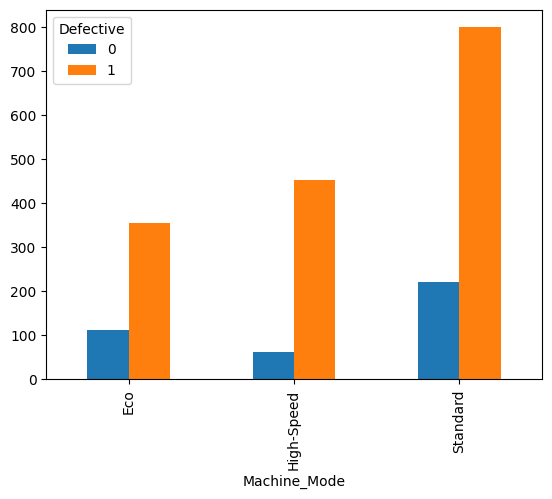

In [86]:
pd.crosstab(df['Machine_Mode'],df['Defective']).plot(kind='bar')

<Axes: xlabel='Maintenance_Level'>

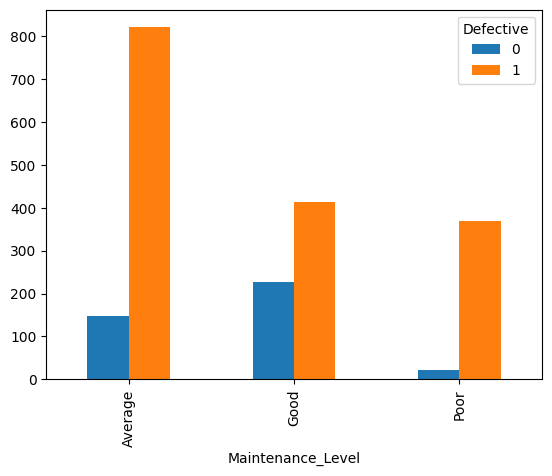

In [87]:
pd.crosstab(df['Maintenance_Level'],df['Defective']).plot(kind='bar')

<Axes: xlabel='Shift_Type'>

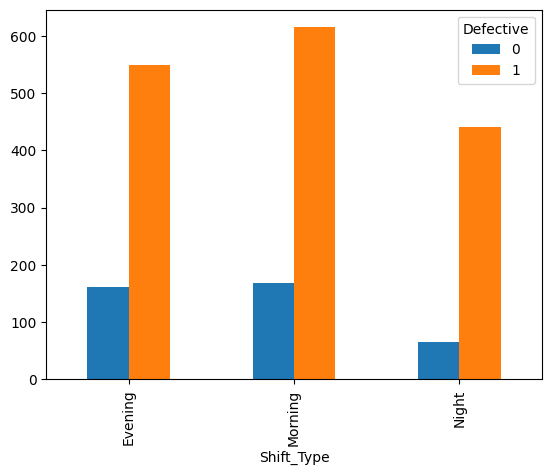

In [88]:
pd.crosstab(df['Shift_Type'],df['Defective']).plot(kind='bar')

In [89]:
# Re-define subdf for robustness in case previous cell was not run
subdf = df[['RPM','Vibration','Pressure','Humidity','Voltage','Current','Load','Operating_Hours','Machine_Mode','Maintenance_Level','Shift_Type']]
new_sub=subdf.drop(['Humidity','Voltage','Current'],axis='columns')
new_sub.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type
0,1660,5.17,88.80,51.93,937,High-Speed,Average,Morning
1,4572,0.61,32.04,31.48,9329,Standard,Poor,Evening
2,3892,4.68,113.85,72.09,5946,High-Speed,Average,Evening
3,1266,4.54,38.12,60.90,8563,Standard,Poor,Night
4,4244,4.53,82.28,16.97,2469,Eco,Average,Morning


In [90]:
merged=pd.concat([new_sub,machine_mode_dummies,Maintenance_dummies,shift_dummies],axis='columns')
merged.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_Mode,Maintenance_Level,Shift_Type,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
0,1660,5.17,88.80,51.93,937,High-Speed,Average,Morning,False,True,False,True,False,False,False,True,False
1,4572,0.61,32.04,31.48,9329,Standard,Poor,Evening,False,False,True,False,False,True,True,False,False
2,3892,4.68,113.85,72.09,5946,High-Speed,Average,Evening,False,True,False,True,False,False,True,False,False
3,1266,4.54,38.12,60.90,8563,Standard,Poor,Night,False,False,True,False,False,True,False,False,True
4,4244,4.53,82.28,16.97,2469,Eco,Average,Morning,True,False,False,True,False,False,False,True,False


In [91]:
final=merged.drop(['Machine_Mode',"Maintenance_Level","Shift_Type"],axis='columns')
final.head()


,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
0,1660,5.17,88.80,51.93,937,False,True,False,True,False,False,False,True,False
1,4572,0.61,32.04,31.48,9329,False,False,True,False,False,True,True,False,False
2,3892,4.68,113.85,72.09,5946,False,True,False,True,False,False,True,False,False
3,1266,4.54,38.12,60.90,8563,False,False,True,False,False,True,False,False,True
4,4244,4.53,82.28,16.97,2469,True,False,False,True,False,False,False,True,False


In [92]:
y=df['Defective']
y

,Defective
0,1
1,1
2,1
3,1
4,1
...,...
1995,0
1996,1
1997,1
1998,1


In [93]:
y=df['Defective']
x_train,x_test,y_train,y_test=train_test_split(final,y,test_size=0.2)
x_train.head()

,RPM,Vibration,Pressure,Load,Operating_Hours,Machine_mode_Eco,Machine_mode_High-Speed,Machine_mode_Standard,Maintenance_Level_Average,Maintenance_Level_Good,Maintenance_Level_Poor,shift_Type_Evening,shift_Type_Morning,shift_Type_Night
1024,4463,5.74,60.19,65.43,4272,False,False,True,False,True,False,False,True,False
1325,3648,1.03,28.32,36.41,8564,True,False,False,False,True,False,True,False,False
190,2856,0.76,34.33,81.01,1588,False,False,True,True,False,False,True,False,False
1605,3979,2.47,99.50,37.25,8505,False,False,True,False,True,False,True,False,False
937,2906,4.68,83.56,80.11,4388,False,False,True,True,False,False,False,True,False


In [94]:
y_train

,Defective
1024,1
1325,0
190,1
1605,1
937,1
...,...
1903,1
218,0
1247,1
656,1


In [95]:
from sklearn import linear_model
logistic=linear_model.LogisticRegression()
logistic.fit(x_train,y_train)
logistic.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,

In [96]:
logistic.score(x_test,y_test)

0.8675